# Fine-tuning một mô hình reranker `BAAI/bge-reranker-v2-m3` cho truy xuất văn bản pháp luật tiếng Việt

## 0. Mục tiêu bài toán

Bài toán được mô hình hóa như một bài toán **reranking** trong hệ thống truy xuất văn bản pháp luật tiếng Việt. Với một câu hỏi pháp luật `query` và một danh sách các đoạn văn bản ứng viên `passages`, mô hình cần xếp đoạn đúng hoặc liên quan nhất lên vị trí cao nhất.

Trong pipeline RAG, reranker thường được đặt sau bước truy xuất ban đầu:

```text
User query
    ↓
Retriever / BM25 / FAISS lấy top-k documents
    ↓
Reranker chấm điểm từng cặp (query, passage)
    ↓
Sắp xếp lại candidates theo điểm reranker
    ↓
Đưa top passages vào LLM hoặc trả kết quả cho người dùng
```

Mục tiêu chính:

1. Fine-tune `BAAI/bge-reranker-v2-m3` trên dữ liệu legal QA tiếng Việt.
2. So sánh mô hình sau fine-tune với baseline là chính mô hình `BAAI/bge-reranker-v2-m3` ở trạng thái pretrained, chưa fine-tune.
3. Xuất đầy đủ số liệu, bảng biểu và hình ảnh phục vụ báo cáo.


## 1. Cài đặt thư viện


In [14]:
!pip install -U torch transformers datasets accelerate scikit-learn tqdm pandas sentencepiece protobuf matplotlib

In [15]:
# Fix lỗi torchvision trước khi import transformers.
# Với bài toán NLP reranking, notebook không cần torchvision.
import os
import sys
import subprocess

os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"

subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "torchvision"],
    check=False,
)

import gc
import json
import math
import random
import inspect
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from datasets import load_dataset
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

print("Đã cấu hình môi trường và import thư viện.")


Đã cấu hình môi trường và import thư viện.


## 2. Mount Google Drive và thiết lập thư mục làm việc


In [16]:
import os

from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = "/content/drive/MyDrive"
PROJECT_DIR = "/content/drive/MyDrive/Project_ML"

if not os.path.exists(DRIVE_DIR):
    raise RuntimeError("Google Drive chưa được mount thành công.")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

print("Project dir:", PROJECT_DIR)
print("Current working directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir: /content/drive/MyDrive/Project_ML
Current working directory: /content/drive/MyDrive/Project_ML


## 3. Import thư viện và cấu hình thí nghiệm

Tỷ lệ chia dữ liệu được đặt là **70/15/15** cho Train/Validation/Test.

Lý do lựa chọn:

- **Train 70%**: đủ lớn để fine-tune mô hình.
- **Validation 15%**: dùng để theo dõi loss/metric theo epoch và chọn checkpoint tốt.
- **Test 15%**: chỉ dùng cho đánh giá cuối cùng, tránh dùng test để điều chỉnh mô hình.

Vì reranker tiêu tốn VRAM theo số cặp `(query, passage)`, batch size được tính theo **số query-group**, không phải số cặp văn bản.

In [17]:
# ===== Cấu hình chính =====
MODEL_NAME = "BAAI/bge-reranker-v2-m3"
OUTPUT_PATH = "./vietlaw-bge-reranker-v2-m3-finetuned"

SEED = 42

# Chia dữ liệu theo yêu cầu báo cáo: Train / Validation / Test.
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
assert abs(TRAIN_SIZE + VAL_SIZE + TEST_SIZE - 1.0) < 1e-9

# BGE reranker v2-m3 hỗ trợ ngữ cảnh dài, nhưng training dài rất tốn VRAM.
MAX_LENGTH = 512

# Mỗi query trong train có 1 positive + TRAIN_NEGATIVES_PER_QUERY negatives.
TRAIN_NEGATIVES_PER_QUERY = 3

# Batch size tính theo số query-group, không phải số cặp.
# Số forward pairs thực tế = PER_DEVICE_TRAIN_BATCH_SIZE * (1 + TRAIN_NEGATIVES_PER_QUERY)
PER_DEVICE_TRAIN_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 8

EPOCHS = 2
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.10
WEIGHT_DECAY = 0.01

# Sinh negative: "tfidf" tạo semi-hard/hard negatives; "random" nhanh hơn nhưng dễ hơn.
NEGATIVE_STRATEGY = "tfidf"   # "tfidf" hoặc "random"
TFIDF_TOP_K_POOL = 50

# Validation/test cũng dùng hard negatives thay vì random negatives.
# Validation group dùng số negative bằng train để tính eval_loss/eval_mrr trong Trainer.
VAL_NEGATIVES_PER_QUERY = TRAIN_NEGATIVES_PER_QUERY

# Evaluation ranking cuối: 1 positive + EVAL_NEGATIVES_PER_QUERY hard negatives.
EVAL_NEGATIVES_PER_QUERY = 31
EVAL_TFIDF_TOP_K_POOL = 100

# Đánh giá baseline là cùng model pretrained trước khi fine-tune.
RUN_BASELINE_EVAL = True

# Log train và validation đồng bộ theo step.
# Ví dụ EPOCHS=2 và LOG_EVALS_PER_EPOCH=4 thì có khoảng 8 điểm val trên learning curve.
LOG_EVALS_PER_EPOCH = 4

# Early stopping dựa trên validation MRR.
EARLY_STOPPING_PATIENCE = 2
EARLY_STOPPING_THRESHOLD = 0.0005

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Không giới hạn số lượng mẫu ở các tập.
MAX_TRAIN_QUERIES = None
MAX_VAL_QUERIES = None
MAX_TEST_QUERIES = None

# Không giới hạn số lượng query dùng để đánh giá validation/test.
MAX_VALIDATION_QUERIES = None

print("Thiết bị:", DEVICE)
print("Tỷ lệ chia dữ liệu:", {"train": TRAIN_SIZE, "validation": VAL_SIZE, "test": TEST_SIZE})
print("Validation/test negatives:", "TF-IDF hard negatives")


Thiết bị: cuda
Tỷ lệ chia dữ liệu: {'train': 0.7, 'validation': 0.15, 'test': 0.15}
Validation/test negatives: TF-IDF hard negatives


In [18]:
# Cố định thêm một số nguồn ngẫu nhiên để kết quả dễ tái lập hơn.
os.environ["PYTHONHASHSEED"] = str(SEED)

# Cấu hình deterministic có thể làm chậm nhẹ, nhưng giúp báo cáo ổn định hơn.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Đã cố định random seed:", SEED)


Đã cố định random seed: 42


## 4. Tải và chuẩn hóa dữ liệu


In [19]:
def _clean_text(x) -> str:
    if x is None:
        return ""
    if isinstance(x, (list, tuple)):
        x = " ".join([str(i) for i in x])
    return str(x).strip()


def _parse_generated_qa_pairs(value):
    """Dataset thangvip thường là list[dict], nhưng hàm này cũng xử lý trường hợp bị lưu dạng string."""
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return []
        try:
            return json.loads(value)
        except Exception:
            pass
        try:
            import ast
            return ast.literal_eval(value)
        except Exception:
            return []
    return []


def load_adamwhite625():
    print("Đang tải dataset: adamwhite625/vietnam-legal-qa...")
    try:
        ds = load_dataset("adamwhite625/vietnam-legal-qa", split="train")
        standardized_data = []
        for row in ds:
            q = _clean_text(row.get("question", ""))
            a = _clean_text(row.get("law_content", ""))
            if q and a and len(a) > 50:
                standardized_data.append({"query": q, "pos": a, "source": "adamwhite625/vietnam-legal-qa"})
        print(f"-> Thu thập được {len(standardized_data)} cặp.")
        return standardized_data
    except Exception as e:
        print(f"Lỗi khi tải adamwhite625/vietnam-legal-qa: {e}")
        return []


def load_huyydangg():
    print("Đang tải dataset: huyydangg/LEGAL-EVAL-Dataset...")
    try:
        ds = load_dataset("huyydangg/LEGAL-EVAL-Dataset", split="test")
        standardized_data = []
        for row in ds:
            q = _clean_text(row.get("anchor", ""))
            a = _clean_text(row.get("positive", ""))
            if q and a and len(a) > 50:
                standardized_data.append({"query": q, "pos": a, "source": "huyydangg/LEGAL-EVAL-Dataset"})
        print(f"-> Thu thập được {len(standardized_data)} cặp.")
        return standardized_data
    except Exception as e:
        print(f"Lỗi khi tải huyydangg/LEGAL-EVAL-Dataset: {e}")
        return []


def load_thangvip():
    print("Đang tải dataset: thangvip/vietnamese-legal-qa...")
    try:
        ds = load_dataset("thangvip/vietnamese-legal-qa", split="train")
        standardized_data = []
        for row in ds:
            qa_pairs = _parse_generated_qa_pairs(row.get("generated_qa_pairs", []))
            if not isinstance(qa_pairs, list):
                continue
            for pair in qa_pairs:
                if not isinstance(pair, dict):
                    continue
                q = _clean_text(pair.get("question", ""))
                a = _clean_text(pair.get("answer", ""))
                if q and a and len(a) > 50:
                    standardized_data.append({"query": q, "pos": a, "source": "thangvip/vietnamese-legal-qa"})
        print(f"-> Thu thập được {len(standardized_data)} cặp.")
        return standardized_data
    except Exception as e:
        print(f"Lỗi khi tải thangvip/vietnamese-legal-qa: {e}")
        return []


def deduplicate_pairs(data: List[Dict[str, str]]) -> List[Dict[str, str]]:
    seen = set()
    deduped = []
    for item in data:
        q = _clean_text(item.get("query"))
        p = _clean_text(item.get("pos"))
        key = (q, p)
        if q and p and key not in seen:
            seen.add(key)
            deduped.append({**item, "query": q, "pos": p})
    return deduped


In [20]:
data1 = load_adamwhite625()
data2 = load_huyydangg()
data3 = load_thangvip()

all_data = deduplicate_pairs(data1 + data2 + data3)

def normalize_text(text):
    return " ".join(str(text).strip().lower().split())

def split_by_passage_group(data, train_size=0.7, val_size=0.15, seed=42):
    """
    Chia dữ liệu theo nhóm passage.
    Tất cả sample có cùng positive passage sẽ nằm trong cùng một tập.
    Mục tiêu: giảm/loại bỏ passage overlap giữa Train/Validation/Test.
    """
    rng = random.Random(seed)

    passage_groups = {}
    for item in data:
        passage_key = normalize_text(item["pos"])
        passage_groups.setdefault(passage_key, []).append(item)

    groups = list(passage_groups.values())
    rng.shuffle(groups)

    n_total = len(data)
    targets = {
        "train": int(n_total * train_size),
        "val": int(n_total * val_size),
        "test": n_total - int(n_total * train_size) - int(n_total * val_size),
    }

    splits = {
        "train": [],
        "val": [],
        "test": [],
    }

    for group in groups:
        # Chọn tập đang thiếu dữ liệu nhiều nhất theo tỷ lệ target
        best_split = min(
            splits.keys(),
            key=lambda name: len(splits[name]) / max(targets[name], 1)
        )
        splits[best_split].extend(group)

    # Shuffle lại trong từng split để tránh dữ liệu bị gom theo passage
    for name in splits:
        rng.shuffle(splits[name])

    return splits["train"], splits["val"], splits["test"]

train_data, val_data, test_data = split_by_passage_group(
    all_data,
    train_size=TRAIN_SIZE,
    val_size=VAL_SIZE,
    seed=SEED
)

n_total = len(all_data)

if MAX_TRAIN_QUERIES is not None:
    train_data = train_data[:MAX_TRAIN_QUERIES]

if MAX_VAL_QUERIES is not None:
    val_data = val_data[:MAX_VAL_QUERIES]

if MAX_TEST_QUERIES is not None:
    test_data = test_data[:MAX_TEST_QUERIES]

eval_val_data = val_data[:MAX_VALIDATION_QUERIES] if MAX_VALIDATION_QUERIES is not None else val_data
eval_test_data = test_data[:MAX_TEST_QUERIES] if MAX_TEST_QUERIES is not None else test_data

print(f"Tổng số cặp Q&A hợp lệ sau deduplicate: {n_total}")
print(f"Số lượng Train: {len(train_data)}")
print(f"Số lượng Validation gốc: {len(val_data)}")
print(f"Số lượng Test gốc: {len(test_data)}")
print(f"Số lượng Validation dùng khi chạy nhanh: {len(eval_val_data)}")
print(f"Số lượng Test dùng khi chạy nhanh: {len(eval_test_data)}")

assert len(train_data) > 0 and len(val_data) > 0 and len(test_data) > 0, "Không có đủ dữ liệu để chia Train/Validation/Test."

split_summary = pd.DataFrame([
    {"Tập dữ liệu": "Train", "Số mẫu": len(train_data), "Tỷ lệ dự kiến": f"{TRAIN_SIZE:.0%}", "Vai trò": "Huấn luyện mô hình"},
    {"Tập dữ liệu": "Validation", "Số mẫu": len(val_data), "Tỷ lệ dự kiến": f"{VAL_SIZE:.0%}", "Vai trò": "Theo dõi learning curves và chọn checkpoint"},
    {"Tập dữ liệu": "Test", "Số mẫu": len(test_data), "Tỷ lệ dự kiến": f"{TEST_SIZE:.0%}", "Vai trò": "Đánh giá cuối cùng"},
])

print("Bảng 2. Thống kê số mẫu theo từng tập dữ liệu")
display(split_summary)

source_summary = pd.Series([x["source"] for x in all_data]).value_counts().reset_index()
source_summary.columns = ["Nguồn dữ liệu", "Số mẫu"]
print("Bảng 3. Phân bố mẫu theo nguồn dữ liệu")
display(source_summary)

Đang tải dataset: adamwhite625/vietnam-legal-qa...
-> Thu thập được 4837 cặp.
Đang tải dataset: huyydangg/LEGAL-EVAL-Dataset...
-> Thu thập được 3873 cặp.
Đang tải dataset: thangvip/vietnamese-legal-qa...
-> Thu thập được 29140 cặp.
Tổng số cặp Q&A hợp lệ sau deduplicate: 37781
Số lượng Train: 26446
Số lượng Validation gốc: 5667
Số lượng Test gốc: 5668
Số lượng Validation dùng khi chạy nhanh: 5667
Số lượng Test dùng khi chạy nhanh: 5668
Bảng 2. Thống kê số mẫu theo từng tập dữ liệu


,Tập dữ liệu,Số mẫu,Tỷ lệ dự kiến,Vai trò
0,Train,26446,70%,Huấn luyện mô hình
1,Validation,5667,15%,Theo dõi learning curves và chọn checkpoint
2,Test,5668,15%,Đánh giá cuối cùng


Bảng 3. Phân bố mẫu theo nguồn dữ liệu


,Nguồn dữ liệu,Số mẫu
0,thangvip/vietnamese-legal-qa,29138
1,adamwhite625/vietnam-legal-qa,4837
2,huyydangg/LEGAL-EVAL-Dataset,3806


In [21]:
overlap_summary = pd.DataFrame([
    {"Loại overlap": "Train-Val query", "Số lượng": len(train_queries & val_queries)},
    {"Loại overlap": "Train-Test query", "Số lượng": len(train_queries & test_queries)},
    {"Loại overlap": "Val-Test query", "Số lượng": len(val_queries & test_queries)},
    {"Loại overlap": "Train-Val passage", "Số lượng": len(train_passages & val_passages)},
    {"Loại overlap": "Train-Test passage", "Số lượng": len(train_passages & test_passages)},
    {"Loại overlap": "Val-Test passage", "Số lượng": len(val_passages & test_passages)},
])

print("Bảng kiểm tra overlap giữa các tập dữ liệu")
display(overlap_summary)

Bảng kiểm tra overlap giữa các tập dữ liệu


,Loại overlap,Số lượng
0,Train-Val query,6
1,Train-Test query,5
2,Val-Test query,1
3,Train-Val passage,0
4,Train-Test passage,0
5,Val-Test passage,0


### 4.1. Tiền xử lý dữ liệu

Các bước tiền xử lý đã áp dụng:

1. **Chuẩn hóa trường dữ liệu**: gom nhiều schema khác nhau về `query` và `pos`.
2. **Làm sạch chuỗi**: chuyển list/tuple sang chuỗi, loại bỏ khoảng trắng đầu/cuối.
3. **Lọc mẫu thiếu hoặc quá ngắn**: bỏ các mẫu không có câu hỏi/câu trả lời hoặc `pos` quá ngắn.
4. **Parse trường QA dạng JSON/string**: áp dụng cho dataset có trường `generated_qa_pairs`.
5. **Deduplicate**: loại bỏ cặp `(query, pos)` trùng nhau.
6. **Tokenization theo cặp**: tokenizer nhận đồng thời `(query, passage)`.
7. **Truncation**: nếu tổng độ dài `query + passage + special tokens` vượt `MAX_LENGTH`, phần dư sẽ bị cắt. Với dữ liệu pháp luật, phần bị cắt thường là đuôi của `passage` vì `query` thường ngắn hơn nhiều.
8. **Negative sampling**: sinh các đoạn không liên quan để mô hình học phân biệt positive với negatives.

Không dùng tăng cường dữ liệu ngôn ngữ vì trong bài toán pháp luật, việc paraphrase tự động có thể làm sai nghĩa pháp lý.


## 5. Lựa chọn mô hình và lý do

Notebook này chỉ thực hiện **một mô hình reranking**: `BAAI/bge-reranker-v2-m3`.

**Bảng 4. Mô hình được huấn luyện và đánh giá trong notebook**

| Mô hình | Loại | Vai trò | Lý do chọn |
|---|---|---|---|
| `BAAI/bge-reranker-v2-m3` | Cross-encoder reranker đa ngôn ngữ | Mô hình chính | Phù hợp với bài toán chấm điểm trực tiếp cặp `query` - `passage`, hỗ trợ nhiều ngôn ngữ và có khả năng xử lý văn bản dài hơn nhiều reranker thông thường. |

Trong bài toán reranking, cross-encoder thường chính xác hơn bi-encoder ở bước sắp xếp lại vì mô hình được nhìn thấy đồng thời cả `query` và `passage`, cho phép attention trực tiếp giữa hai văn bản.

Hai mô hình reranking khác sẽ được thực hiện trong notebook riêng của các thành viên khác, sau đó nhóm có thể ghép kết quả vào một bảng so sánh chung trong báo cáo cuối.


Trong phần thực nghiệm, notebook cũng đánh giá **baseline pretrained** của cùng mô hình trước fine-tune. Đây không được tính là mô hình thứ hai độc lập, mà là mốc tham chiếu để đo mức cải thiện do fine-tuning.

## 5.1. Tạo hard negatives cho reranker

Notebook dùng TF-IDF để tạo **hard negatives** cho cả train, validation và test. Các negative này không được lấy ngẫu nhiên thuần túy, mà là những passage có độ tương đồng từ vựng cao với query nhưng không phải positive passage. Cách này làm bài toán khó hơn và sát thực tế hơn vì mô hình phải phân biệt các đoạn văn bản pháp luật có nội dung gần nhau.

- Train: dùng hard negatives để học groupwise ranking loss.
- Validation: dùng hard negatives để tính `eval_loss`, `eval_top1_accuracy`, `eval_mrr` trong quá trình training.
- Test: dùng hard negatives để báo cáo ranking metrics cuối cùng.


In [22]:
def random_negatives_for_index(
    idx: int,
    data: List[Dict[str, str]],
    num_negatives: int,
    rng: random.Random,
) -> List[str]:
    pos = data[idx]["pos"]
    n = len(data)
    negatives = []
    attempts = 0
    while len(negatives) < num_negatives and attempts < 500:
        j = rng.randrange(n)
        candidate = data[j]["pos"]
        if j != idx and candidate != pos and candidate not in negatives:
            negatives.append(candidate)
        attempts += 1

    # Fallback tuyến tính nếu random chưa đủ.
    if len(negatives) < num_negatives:
        for j, item in enumerate(data):
            candidate = item["pos"]
            if j != idx and candidate != pos and candidate not in negatives:
                negatives.append(candidate)
                if len(negatives) == num_negatives:
                    break
    return negatives


def build_random_negatives(
    data: List[Dict[str, str]],
    num_negatives: int,
    seed: int = 42,
) -> List[List[str]]:
    rng = random.Random(seed)
    return [random_negatives_for_index(i, data, num_negatives, rng) for i in tqdm(range(len(data)), desc="Random negatives")]


def build_tfidf_negatives(
    data: List[Dict[str, str]],
    num_negatives: int,
    top_k_pool: int = 50,
    seed: int = 42,
    batch_size: int = 128,
    desc: str = "TF-IDF hard negatives",
) -> List[List[str]]:
    """Sinh hard negatives bằng TF-IDF.

    Với mỗi query, hàm lấy các passage có độ giống TF-IDF cao nhất nhưng không phải positive.
    Đây là negative sampling khó hơn random vì các passage sai thường có từ khóa gần với query.
    """
    rng = random.Random(seed)
    queries = [x["query"] for x in data]
    passages = [x["pos"] for x in data]
    n = len(data)

    if n <= 1:
        return [[] for _ in data]

    print(f"Đang fit TF-IDF trên {n} passages để tạo {desc}...")
    vectorizer = TfidfVectorizer(
        lowercase=True,
        max_features=100_000,
        ngram_range=(1, 2),
        min_df=2,
    )
    doc_matrix = vectorizer.fit_transform(passages)
    query_matrix = vectorizer.transform(queries)

    all_negatives = []
    k = min(top_k_pool + 1, n)

    for start in tqdm(range(0, n, batch_size), desc=desc):
        end = min(start + batch_size, n)
        sims = query_matrix[start:end].dot(doc_matrix.T).toarray()

        for local_i, scores in enumerate(sims):
            idx = start + local_i
            pos = passages[idx]

            # Lấy top-k ứng viên giống query nhất.
            if k < n:
                candidate_idx = np.argpartition(-scores, kth=k - 1)[:k]
            else:
                candidate_idx = np.arange(n)

            candidate_idx = candidate_idx[np.argsort(-scores[candidate_idx])]

            negatives = []
            for j in candidate_idx:
                candidate = passages[int(j)]
                if int(j) != idx and candidate != pos and candidate not in negatives:
                    negatives.append(candidate)
                if len(negatives) == num_negatives:
                    break

            # Fallback random nếu top-k chưa đủ negative.
            if len(negatives) < num_negatives:
                extra = random_negatives_for_index(idx, data, num_negatives - len(negatives), rng)
                for item in extra:
                    if item not in negatives:
                        negatives.append(item)
                    if len(negatives) == num_negatives:
                        break

            all_negatives.append(negatives)

    return all_negatives


# 1) Train negatives.
if NEGATIVE_STRATEGY == "tfidf":
    train_negatives = build_tfidf_negatives(
        train_data,
        num_negatives=TRAIN_NEGATIVES_PER_QUERY,
        top_k_pool=TFIDF_TOP_K_POOL,
        seed=SEED,
        desc="Train TF-IDF hard negatives",
    )
elif NEGATIVE_STRATEGY == "random":
    train_negatives = build_random_negatives(
        train_data,
        num_negatives=TRAIN_NEGATIVES_PER_QUERY,
        seed=SEED,
    )
else:
    raise ValueError("NEGATIVE_STRATEGY phải là 'tfidf' hoặc 'random'.")

# 2) Validation negatives cho Trainer: dùng hard negatives để eval_loss/eval_mrr khó hơn random.
val_group_negatives = build_tfidf_negatives(
    eval_val_data,
    num_negatives=VAL_NEGATIVES_PER_QUERY,
    top_k_pool=TFIDF_TOP_K_POOL,
    seed=SEED + 13,
    desc="Validation group TF-IDF hard negatives",
)

# 3) Validation/test ranking negatives: dùng hard negatives cho đánh giá ranking.
# Validation ranking negatives có thể dùng khi cần phân tích thêm trên validation set.
val_ranking_negatives = build_tfidf_negatives(
    eval_val_data,
    num_negatives=EVAL_NEGATIVES_PER_QUERY,
    top_k_pool=EVAL_TFIDF_TOP_K_POOL,
    seed=SEED + 23,
    desc="Validation ranking TF-IDF hard negatives",
)

test_ranking_negatives = build_tfidf_negatives(
    eval_test_data,
    num_negatives=EVAL_NEGATIVES_PER_QUERY,
    top_k_pool=EVAL_TFIDF_TOP_K_POOL,
    seed=SEED + 29,
    desc="Test ranking TF-IDF hard negatives",
)

print("Ví dụ training group:")
print("Query:", train_data[0]["query"][:300])
print("\nPositive:", train_data[0]["pos"][:300])
for i, neg in enumerate(train_negatives[0], 1):
    print(f"\nHard negative {i}:", neg[:300])

print("\nVí dụ test hard negatives:")
print("Query:", eval_test_data[0]["query"][:300])
for i, neg in enumerate(test_ranking_negatives[0][:3], 1):
    print(f"\nTest hard negative {i}:", neg[:300])


Đang fit TF-IDF trên 26446 passages để tạo Train TF-IDF hard negatives...


Train TF-IDF hard negatives:   0%|          | 0/207 [00:00<?, ?it/s]

Đang fit TF-IDF trên 5667 passages để tạo Validation group TF-IDF hard negatives...


Validation group TF-IDF hard negatives:   0%|          | 0/45 [00:00<?, ?it/s]

Đang fit TF-IDF trên 5667 passages để tạo Validation ranking TF-IDF hard negatives...


Validation ranking TF-IDF hard negatives:   0%|          | 0/45 [00:00<?, ?it/s]

Đang fit TF-IDF trên 5668 passages để tạo Test ranking TF-IDF hard negatives...


Test ranking TF-IDF hard negatives:   0%|          | 0/45 [00:00<?, ?it/s]

Ví dụ training group:
Query: Giả sử một người đang được trợ giúp pháp lý nhưng sau đó muốn chấm dứt yêu cầu, đồng thời lo ngại thông tin cá nhân bị tiết lộ và nghi ngờ có thiệt hại xảy ra trong quá trình trợ giúp pháp lý. Dựa trên Điều 8, người này có những quyền gì để giải quyết các vấn đề trên?

Positive: Dựa trên Điều 8 của Luật Trợ giúp pháp lý, trong tình huống này, người được trợ giúp pháp lý có các quyền sau:
1.  **Quyền thay đổi, rút yêu cầu trợ giúp pháp lý:** Theo khoản 6 Điều 8, người này có quyền thay đổi hoặc rút yêu cầu trợ giúp pháp lý bất cứ lúc nào. Điều này cho phép họ chấm dứt quá tr

Hard negative 1: Điều 6 Khoản 1 Điểm c của Luật Trợ giúp pháp lý quy định nghiêm cấm tổ chức và người thực hiện trợ giúp pháp lý tiết lộ thông tin về vụ việc trợ giúp pháp lý, về người được trợ giúp pháp lý. Tuy nhiên, có hai trường hợp ngoại lệ mà việc tiết lộ thông tin không bị coi là hành vi nghiêm cấm: 1) Khi ng

Hard negative 2: Theo Khoản 1 Điều 26 Luật Trợ giúp pháp lý, Trung tâm

## 6. Dataset, collator, kiến trúc và loss groupwise cho reranker

Mỗi sample huấn luyện là một group có `1 positive + K negatives`. Positive luôn được đặt ở vị trí 0, do đó nhãn đúng của mỗi group là class `0`.

Hàm mất mát:

```text
CrossEntropyLoss(scores_of_group, label=0)
```

Ý nghĩa: mô hình học để score của positive cao hơn các negative trong cùng group.

In [23]:
class RerankerGroupDataset(Dataset):
    def __init__(self, data: List[Dict[str, str]], negatives: List[List[str]]):
        assert len(data) == len(negatives)
        self.data = data
        self.negatives = negatives

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        passages = [item["pos"]] + self.negatives[idx]
        return {
            "query": item["query"],
            "passages": passages,
        }


@dataclass
class RerankerGroupCollator:
    tokenizer: AutoTokenizer
    max_length: int

    def __call__(self, features):
        group_size = len(features[0]["passages"])
        queries = []
        passages = []

        for feature in features:
            assert len(feature["passages"]) == group_size, "Mọi group phải có cùng số passage."
            queries.extend([feature["query"]] * group_size)
            passages.extend(feature["passages"])

        batch = self.tokenizer(
            queries,
            passages,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        batch["group_size"] = torch.tensor(group_size, dtype=torch.long)
        # Label 0 vì positive passage luôn đứng đầu group.
        batch["labels"] = torch.zeros(len(features), dtype=torch.long)
        return batch


class GroupwiseRerankerTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        group_size = int(inputs.pop("group_size").item())
        labels = inputs.pop("labels", None)
        outputs = model(**inputs)
        logits = outputs.logits.view(-1, group_size)

        if labels is None:
            labels = torch.zeros(logits.size(0), dtype=torch.long, device=logits.device)
        else:
            labels = labels.to(logits.device)

        loss = F.cross_entropy(logits, labels)
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only=False, ignore_keys=None):
        inputs = self._prepare_inputs(inputs)
        group_size = int(inputs.pop("group_size").item())
        labels = inputs.pop("labels", None)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits.view(-1, group_size)
            if labels is None:
                labels = torch.zeros(logits.size(0), dtype=torch.long, device=logits.device)
            else:
                labels = labels.to(logits.device)
            loss = F.cross_entropy(logits, labels)

        if prediction_loss_only:
            return (loss.detach(), None, None)

        return (loss.detach(), logits.detach(), labels.detach())


def compute_group_metrics(eval_pred):
    logits, labels = eval_pred
    logits = np.asarray(logits)
    labels = np.asarray(labels)

    preds = np.argmax(logits, axis=1)
    top1_accuracy = float(np.mean(preds == labels))

    ranks = []
    for row, label in zip(logits, labels):
        sorted_idx = np.argsort(-row)
        rank = int(np.where(sorted_idx == label)[0][0]) + 1
        ranks.append(rank)

    mrr = float(np.mean([1.0 / r for r in ranks]))
    return {
        "top1_accuracy": top1_accuracy,
        "mrr": mrr,
    }


train_dataset = RerankerGroupDataset(train_data, train_negatives)
val_group_dataset = RerankerGroupDataset(eval_val_data, val_group_negatives)

print("Số training groups:", len(train_dataset))
print("Số validation groups dùng khi train:", len(val_group_dataset))
print("Group size:", 1 + TRAIN_NEGATIVES_PER_QUERY)

Số training groups: 26446
Số validation groups dùng khi train: 5667
Group size: 4


## 6.1. Load model và mô tả kiến trúc

Mô hình chính là một **cross-encoder reranker**. Input của mô hình là cặp `(query, passage)`, sau đó Transformer encoder mã hóa đồng thời cả hai đoạn và classification head trả về một logit relevance.

Các thông tin quan trọng phục vụ báo cáo:

- Số tham số tổng.
- Số tham số được fine-tune.
- Hàm kích hoạt trong config.
- Sơ đồ kiến trúc mức khái quát.

In [24]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# Tiết kiệm VRAM. Có thể tắt nếu gặp lỗi.
if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()

if hasattr(model.config, "use_cache"):
    model.config.use_cache = False

model.to(DEVICE)

num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
hidden_act = getattr(model.config, "hidden_act", "Không có trong config")
num_hidden_layers = getattr(model.config, "num_hidden_layers", "Không có trong config")
hidden_size = getattr(model.config, "hidden_size", "Không có trong config")
num_attention_heads = getattr(model.config, "num_attention_heads", "Không có trong config")

arch_summary = pd.DataFrame([
    {"Thuộc tính": "Model", "Giá trị": MODEL_NAME},
    {"Thuộc tính": "Kiểu mô hình", "Giá trị": "Transformer encoder cross-encoder reranker"},
    {"Thuộc tính": "Số hidden layers", "Giá trị": num_hidden_layers},
    {"Thuộc tính": "Hidden size", "Giá trị": hidden_size},
    {"Thuộc tính": "Số attention heads", "Giá trị": num_attention_heads},
    {"Thuộc tính": "Activation trong config", "Giá trị": hidden_act},
    {"Thuộc tính": "Tổng số tham số", "Giá trị": f"{num_params:,}"},
    {"Thuộc tính": "Số tham số trainable", "Giá trị": f"{num_trainable:,}"},
])
print("Bảng 5. Thông tin kiến trúc và số tham số của mô hình")
display(arch_summary)

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Bảng 5. Thông tin kiến trúc và số tham số của mô hình


,Thuộc tính,Giá trị
0,Model,BAAI/bge-reranker-v2-m3
1,Kiểu mô hình,Transformer encoder cross-encoder reranker
2,Số hidden layers,24
3,Hidden size,1024
4,Số attention heads,16
5,Activation trong config,gelu
6,Tổng số tham số,"567,755,777"
7,Số tham số trainable,"567,755,777"


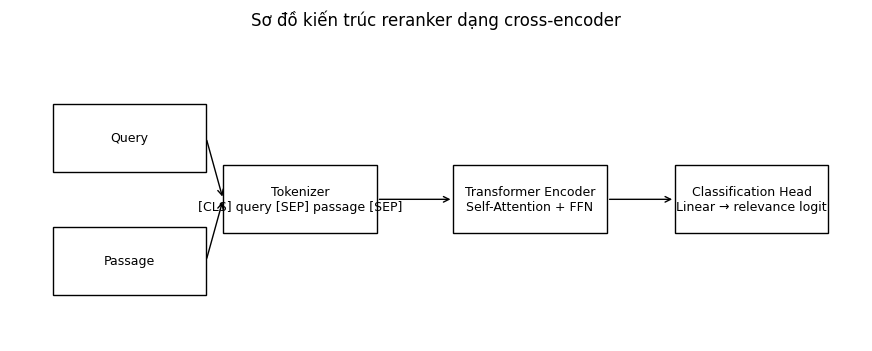

In [25]:
def draw_architecture_diagram():
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.axis("off")

    boxes = [
        (0.05, 0.55, "Query"),
        (0.05, 0.15, "Passage"),
        (0.25, 0.35, "Tokenizer\n[CLS] query [SEP] passage [SEP]"),
        (0.52, 0.35, "Transformer Encoder\nSelf-Attention + FFN"),
        (0.78, 0.35, "Classification Head\nLinear → relevance logit"),
    ]

    for x, y, text in boxes:
        rect = plt.Rectangle((x, y), 0.18, 0.22, fill=False)
        ax.add_patch(rect)
        ax.text(x + 0.09, y + 0.11, text, ha="center", va="center", fontsize=9)

    arrows = [
        ((0.23, 0.66), (0.25, 0.46)),
        ((0.23, 0.26), (0.25, 0.46)),
        ((0.43, 0.46), (0.52, 0.46)),
        ((0.70, 0.46), (0.78, 0.46)),
    ]

    for start, end in arrows:
        ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->"))

    ax.set_title("Sơ đồ kiến trúc reranker dạng cross-encoder")
    plt.show()

draw_architecture_diagram()


*Hình 1. Sơ đồ kiến trúc tổng quát của reranker cross-encoder. Mô hình nhận đồng thời query và passage, sau đó sinh một relevance logit dùng để xếp hạng.*


## 7. Cấu hình huấn luyện và siêu tham số

Mô hình được fine-tune bằng groupwise cross-entropy. Mỗi group gồm 1 positive passage và nhiều hard negative passages. Notebook log train loss và validation metrics theo cùng một mốc step để learning curve đồng bộ hơn. Early stopping được bật dựa trên `eval_mrr` của validation set nhằm tránh train quá lâu khi mô hình không còn cải thiện.


In [26]:
hyperparam_table = pd.DataFrame([
    {"Siêu tham số": "MODEL_NAME", "Giá trị": MODEL_NAME},
    {"Siêu tham số": "MAX_LENGTH", "Giá trị": MAX_LENGTH},
    {"Siêu tham số": "TRAIN_NEGATIVES_PER_QUERY", "Giá trị": TRAIN_NEGATIVES_PER_QUERY},
    {"Siêu tham số": "VAL_NEGATIVES_PER_QUERY", "Giá trị": VAL_NEGATIVES_PER_QUERY},
    {"Siêu tham số": "EVAL_NEGATIVES_PER_QUERY", "Giá trị": EVAL_NEGATIVES_PER_QUERY},
    {"Siêu tham số": "NEGATIVE_STRATEGY", "Giá trị": NEGATIVE_STRATEGY},
    {"Siêu tham số": "TFIDF_TOP_K_POOL", "Giá trị": TFIDF_TOP_K_POOL},
    {"Siêu tham số": "EVAL_TFIDF_TOP_K_POOL", "Giá trị": EVAL_TFIDF_TOP_K_POOL},
    {"Siêu tham số": "PER_DEVICE_TRAIN_BATCH_SIZE", "Giá trị": PER_DEVICE_TRAIN_BATCH_SIZE},
    {"Siêu tham số": "GRADIENT_ACCUMULATION_STEPS", "Giá trị": GRADIENT_ACCUMULATION_STEPS},
    {"Siêu tham số": "EPOCHS", "Giá trị": EPOCHS},
    {"Siêu tham số": "LEARNING_RATE", "Giá trị": LEARNING_RATE},
    {"Siêu tham số": "WARMUP_RATIO", "Giá trị": WARMUP_RATIO},
    {"Siêu tham số": "WEIGHT_DECAY", "Giá trị": WEIGHT_DECAY},
    {"Siêu tham số": "LOG_EVALS_PER_EPOCH", "Giá trị": LOG_EVALS_PER_EPOCH},
    {"Siêu tham số": "EARLY_STOPPING_PATIENCE", "Giá trị": EARLY_STOPPING_PATIENCE},
    {"Siêu tham số": "EARLY_STOPPING_THRESHOLD", "Giá trị": EARLY_STOPPING_THRESHOLD},
])

print("Bảng 7. Cấu hình huấn luyện và siêu tham số")
display(hyperparam_table)


Bảng 7. Cấu hình huấn luyện và siêu tham số


,Siêu tham số,Giá trị
0,MODEL_NAME,BAAI/bge-reranker-v2-m3
1,MAX_LENGTH,512
2,TRAIN_NEGATIVES_PER_QUERY,3
3,VAL_NEGATIVES_PER_QUERY,3
4,EVAL_NEGATIVES_PER_QUERY,31
5,NEGATIVE_STRATEGY,tfidf
6,TFIDF_TOP_K_POOL,50
7,EVAL_TFIDF_TOP_K_POOL,100
8,PER_DEVICE_TRAIN_BATCH_SIZE,2
9,GRADIENT_ACCUMULATION_STEPS,8


## 8. Hàm đánh giá ranking và classification view

Các metric ranking chính:

- `MRR@10`: positive càng đứng cao thì càng tốt.
- `NDCG@10`: chất lượng ranking trong top 10.
- `Recall@k`: tỷ lệ query có positive nằm trong top-k.
- `MeanRank`, `MedianRank`: thứ hạng trung bình/trung vị của positive.

Để đáp ứng yêu cầu báo cáo về `Accuracy/Precision/Recall/F1` và `Confusion Matrix`, notebook bổ sung **top-1 classification view**:

- Với mỗi query, passage được model xếp top 1 được xem là dự đoán `relevant`.
- Passage positive thật là nhãn `relevant`.
- Các passage còn lại là `non-relevant`.

Cách nhìn này phù hợp cho reranking, nhưng cần lưu ý `Accuracy` có thể cao do số negative nhiều.


In [27]:
@torch.no_grad()
def score_pairs(
    model,
    tokenizer,
    pairs: List[Tuple[str, str]],
    batch_size: int = 16,
    max_length: int = 1024,
    normalize: bool = False,
) -> List[float]:
    model.eval()
    scores = []

    for start in range(0, len(pairs), batch_size):
        batch_pairs = pairs[start:start + batch_size]
        queries = [x[0] for x in batch_pairs]
        passages = [x[1] for x in batch_pairs]

        encoded = tokenizer(
            queries,
            passages,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(model.device)

        logits = model(**encoded).logits.view(-1)
        batch_scores = logits.detach().float().cpu().numpy()

        if normalize:
            batch_scores = 1 / (1 + np.exp(-batch_scores))

        scores.extend(batch_scores.tolist())

    return scores


def build_ranking_candidates(
    eval_data: List[Dict[str, str]],
    idx: int,
    num_negatives: int,
    rng: random.Random,
    precomputed_negatives: Optional[List[List[str]]] = None,
) -> Tuple[str, List[str], int]:
    item = eval_data[idx]
    query = item["query"]
    positive = item["pos"]

    negatives = []

    # Ưu tiên hard negatives đã tạo trước bằng TF-IDF.
    if precomputed_negatives is not None:
        for candidate in precomputed_negatives[idx]:
            if candidate != positive and candidate not in negatives:
                negatives.append(candidate)
            if len(negatives) == num_negatives:
                break

    # Fallback random nếu hard negatives chưa đủ.
    attempts = 0
    while len(negatives) < num_negatives and attempts < 1000:
        j = rng.randrange(len(eval_data))
        candidate = eval_data[j]["pos"]
        if j != idx and candidate != positive and candidate not in negatives:
            negatives.append(candidate)
        attempts += 1

    # Fallback tuyến tính nếu eval_data nhỏ.
    if len(negatives) < num_negatives:
        for j, other in enumerate(eval_data):
            candidate = other["pos"]
            if j != idx and candidate != positive and candidate not in negatives:
                negatives.append(candidate)
                if len(negatives) == num_negatives:
                    break

    candidates = [positive] + negatives
    order = list(range(len(candidates)))
    rng.shuffle(order)

    shuffled_candidates = [candidates[i] for i in order]
    positive_new_idx = order.index(0)
    return query, shuffled_candidates, positive_new_idx


def compute_ranking_metrics(ranks: List[int], candidates_per_query: int) -> Dict[str, float]:
    ranks = np.array(ranks)
    metrics = {
        "MRR@10": float(np.mean([1.0 / r if r <= 10 else 0.0 for r in ranks])),
        "NDCG@10": float(np.mean([1.0 / math.log2(r + 1) if r <= 10 else 0.0 for r in ranks])),
        "Recall@1": float(np.mean(ranks <= 1)),
        "Recall@3": float(np.mean(ranks <= 3)),
        "Recall@5": float(np.mean(ranks <= 5)),
        "Recall@10": float(np.mean(ranks <= 10)),
        "MeanRank": float(np.mean(ranks)),
        "MedianRank": float(np.median(ranks)),
        "NumQueries": int(len(ranks)),
        "CandidatesPerQuery": int(candidates_per_query),
    }
    return metrics


def top1_classification_metrics_from_ranks(
    ranks: List[int],
    candidates_per_query: int,
) -> Tuple[Dict[str, float], np.ndarray]:
    ranks = np.array(ranks)
    n = len(ranks)
    tp = int(np.sum(ranks == 1))
    fn = int(n - tp)
    fp = int(n - tp)
    tn = int(n * (candidates_per_query - 1) - fp)

    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    metrics = {
        "Top1_Accuracy": float(accuracy),
        "Top1_Precision": float(precision),
        "Top1_Recall": float(recall),
        "Top1_F1": float(f1),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    }
    cm = np.array([[tn, fp], [fn, tp]])
    return metrics, cm


def evaluate_reranker(
    model,
    tokenizer,
    eval_data: List[Dict[str, str]],
    num_negatives: int = 31,
    batch_size: int = 16,
    max_length: int = 1024,
    seed: int = 42,
    return_details: bool = False,
    precomputed_negatives: Optional[List[List[str]]] = None,
):
    rng = random.Random(seed)
    ranks = []
    details = []

    if precomputed_negatives is not None:
        assert len(precomputed_negatives) == len(eval_data), "precomputed_negatives phải cùng độ dài với eval_data."

    for idx in tqdm(range(len(eval_data)), desc="Evaluating reranker"):
        query, candidates, positive_idx = build_ranking_candidates(
            eval_data,
            idx,
            num_negatives,
            rng,
            precomputed_negatives=precomputed_negatives,
        )
        pairs = [(query, passage) for passage in candidates]
        scores = score_pairs(
            model,
            tokenizer,
            pairs,
            batch_size=batch_size,
            max_length=max_length,
            normalize=False,
        )

        sorted_idx = np.argsort(-np.array(scores))
        rank = int(np.where(sorted_idx == positive_idx)[0][0]) + 1
        ranks.append(rank)

        if return_details:
            top_idx = int(sorted_idx[0])
            details.append({
                "query": query,
                "positive_passage": candidates[positive_idx],
                "predicted_top_passage": candidates[top_idx],
                "positive_rank": rank,
                "positive_score": float(scores[positive_idx]),
                "top_score": float(scores[top_idx]),
                "score_gap_top_minus_positive": float(scores[top_idx] - scores[positive_idx]),
                "candidates_per_query": len(candidates),
                "negative_sampling": "tfidf_hard" if precomputed_negatives is not None else "random",
            })

    metrics = compute_ranking_metrics(ranks, candidates_per_query=1 + num_negatives)
    cls_metrics, cm = top1_classification_metrics_from_ranks(ranks, candidates_per_query=1 + num_negatives)
    metrics.update(cls_metrics)
    metrics["NegativeSampling"] = "tfidf_hard" if precomputed_negatives is not None else "random"

    if return_details:
        return metrics, ranks, cm, pd.DataFrame(details)
    return metrics


def print_metrics(metrics: Dict[str, float]):
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")


## 9. Đánh giá baseline trước fine-tune

Baseline trong notebook này là **cùng kiến trúc `BAAI/bge-reranker-v2-m3` nhưng ở trạng thái pretrained, chưa fine-tune trên dữ liệu pháp luật tiếng Việt**. Baseline được đánh giá trên cùng test set và cùng bộ TF-IDF hard negatives như mô hình sau fine-tune để bảo đảm so sánh công bằng.

Các chỉ số baseline sẽ được dùng làm mốc so sánh trong `Bảng 9`. Nếu mô hình sau fine-tune tốt hơn, các metric như `MRR@10`, `NDCG@10`, `Recall@K`, `Top1_F1` thường tăng, còn `MeanRank` và `MedianRank` thường giảm.

In [28]:
# Đánh giá baseline: model hiện tại vẫn là pretrained vì chưa gọi trainer.train().
# Dùng cùng eval_test_data và cùng test_ranking_negatives để so sánh công bằng với mô hình sau fine-tune.

if RUN_BASELINE_EVAL:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("=" * 60)
    print("ĐÁNH GIÁ BASELINE PRETRAINED TRÊN TEST SET")
    print("=" * 60)
    print("Baseline:", MODEL_NAME, "chưa fine-tune")
    print("Test negative sampling: TF-IDF hard negatives")

    baseline_metrics, baseline_ranks, baseline_cm, baseline_details = evaluate_reranker(
        model,
        tokenizer,
        eval_data=eval_test_data,
        num_negatives=EVAL_NEGATIVES_PER_QUERY,
        batch_size=PER_DEVICE_TRAIN_BATCH_SIZE * (1 + TRAIN_NEGATIVES_PER_QUERY),
        max_length=MAX_LENGTH,
        seed=SEED,
        return_details=True,
        precomputed_negatives=test_ranking_negatives,
    )

    print_metrics(baseline_metrics)

    os.makedirs("./eval_reranker_baseline", exist_ok=True)
    with open("./eval_reranker_baseline/metrics.json", "w", encoding="utf-8") as f:
        json.dump(baseline_metrics, f, ensure_ascii=False, indent=2)

    baseline_details.to_csv("./eval_reranker_baseline/error_details.csv", index=False, encoding="utf-8-sig")
else:
    print("Bỏ qua baseline evaluation vì RUN_BASELINE_EVAL = False.")
    baseline_metrics, baseline_ranks, baseline_cm, baseline_details = {}, [], None, pd.DataFrame()


ĐÁNH GIÁ BASELINE PRETRAINED TRÊN TEST SET
Baseline: BAAI/bge-reranker-v2-m3 chưa fine-tune
Test negative sampling: TF-IDF hard negatives


Evaluating reranker:   0%|          | 0/5668 [00:00<?, ?it/s]

MRR@10: 0.9627
NDCG@10: 0.9694
Recall@1: 0.9458
Recall@3: 0.9771
Recall@5: 0.9834
Recall@10: 0.9898
MeanRank: 1.2733
MedianRank: 1.0000
NumQueries: 5668
CandidatesPerQuery: 32
Top1_Accuracy: 0.9966
Top1_Precision: 0.9458
Top1_Recall: 0.9458
Top1_F1: 0.9458
TP: 5361
FP: 307
FN: 307
TN: 175401
NegativeSampling: tfidf_hard


## 10. Fine-tuning

Trainer được cấu hình để đánh giá trên validation set sau mỗi epoch. Điều này giúp vẽ learning curves và phân tích mô hình có hội tụ/overfit hay không.

In [29]:
# Số update steps mỗi epoch của Trainer có tính gradient accumulation.
updates_per_epoch = max(
    1,
    math.ceil(len(train_dataset) / (PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS))
)
SYNC_EVAL_STEPS = max(1, updates_per_epoch // LOG_EVALS_PER_EPOCH)

print("Updates/epoch:", updates_per_epoch)
print("Log/Eval/Save mỗi", SYNC_EVAL_STEPS, "optimizer steps")
print("Ước tính số điểm validation:", math.ceil(EPOCHS * updates_per_epoch / SYNC_EVAL_STEPS))

training_args_kwargs = dict(
    output_dir=OUTPUT_PATH,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    fp16=torch.cuda.is_available(),

    # Log train và validation đồng bộ theo cùng một step.
    logging_strategy="steps",
    logging_steps=SYNC_EVAL_STEPS,
    save_strategy="steps",
    save_steps=SYNC_EVAL_STEPS,
    save_total_limit=2,

    report_to="none",
    remove_unused_columns=False,
    dataloader_num_workers=2,
    load_best_model_at_end=True,

    # Early stopping sẽ theo dõi eval_mrr trên validation hard negatives.
    metric_for_best_model="eval_mrr",
    greater_is_better=True,
    seed=SEED,
)

# Tương thích nhiều phiên bản transformers: evaluation_strategy cũ và eval_strategy mới.
ta_params = inspect.signature(TrainingArguments.__init__).parameters
if "eval_strategy" in ta_params:
    training_args_kwargs["eval_strategy"] = "steps"
else:
    training_args_kwargs["evaluation_strategy"] = "steps"

# Một số version yêu cầu eval_steps truyền riêng.
training_args_kwargs["eval_steps"] = SYNC_EVAL_STEPS

training_args = TrainingArguments(**training_args_kwargs)

trainer = GroupwiseRerankerTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_group_dataset,
    data_collator=RerankerGroupCollator(tokenizer=tokenizer, max_length=MAX_LENGTH),
    compute_metrics=compute_group_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=EARLY_STOPPING_THRESHOLD,
        )
    ],
)

print("=" * 60)
print("BẮT ĐẦU FINE-TUNING RERANKER")
print("=" * 60)
print(f"Early stopping: patience={EARLY_STOPPING_PATIENCE}, threshold={EARLY_STOPPING_THRESHOLD}")
print("Validation negatives:", "TF-IDF hard negatives")

trainer.train()

trainer.save_model(OUTPUT_PATH)
tokenizer.save_pretrained(OUTPUT_PATH)

print(f"\n✅ Hoàn tất fine-tune. Model đã lưu tại: {OUTPUT_PATH}")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Updates/epoch: 1653
Log/Eval/Save mỗi 413 optimizer steps
Ước tính số điểm validation: 9
BẮT ĐẦU FINE-TUNING RERANKER
Early stopping: patience=2, threshold=0.0005
Validation negatives: TF-IDF hard negatives


Step,Training Loss,Validation Loss,Top1 Accuracy,Mrr
413,1.039847,0.044133,0.985883,0.992662
826,0.875444,0.044785,0.986765,0.993059
1239,0.773522,0.043306,0.987648,0.993574
1652,0.655087,0.042483,0.987648,0.993677
2065,0.376252,0.043034,0.989765,0.994706
2478,0.280195,0.051662,0.989412,0.994574
2891,0.439658,0.042388,0.991177,0.995515
3304,0.320387,0.042962,0.991177,0.995515
3306,0.320387,0.042971,0.991001,0.995427


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Hoàn tất fine-tune. Model đã lưu tại: ./vietlaw-bge-reranker-v2-m3-finetuned


### 10.1. Learning curves: Loss và metric trên Train/Validation

Các biểu đồ dưới đây phục vụ phần **Kết quả thực nghiệm** của báo cáo.  
Train loss và validation loss/metric được ghi tại cùng các mốc step, giúp learning curve đồng bộ dù chỉ train 2 epoch.


Bảng 8a. Log huấn luyện gốc từ Trainer


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_top1_accuracy,eval_mrr,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.039847,251.074677,1.945546e-05,0.249868,413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,0.249868,413,0.044133,0.985883,0.992662,270.8369,20.924,2.618,NaN,NaN,NaN,NaN,NaN
2,0.875444,27.858959,1.667899e-05,0.499735,826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,0.499735,826,0.044785,0.986765,0.993059,271.1183,20.902,2.615,NaN,NaN,NaN,NaN,NaN
4,0.773522,195.883331,1.390252e-05,0.749603,1239,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,0.749603,1239,0.043306,0.987648,0.993574,270.8207,20.925,2.618,NaN,NaN,NaN,NaN,NaN
6,0.655087,0.076318,1.112605e-05,0.999471,1652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,0.999471,1652,0.042483,0.987648,0.993677,270.8348,20.924,2.618,NaN,NaN,NaN,NaN,NaN
8,0.376252,1.902007,8.349580e-06,1.249263,2065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,1.249263,2065,0.043034,0.989765,0.994706,270.8630,20.922,2.618,NaN,NaN,NaN,NaN,NaN


Bảng 8b. Log train/validation đã đồng bộ theo step


,step,epoch,train_loss,eval_loss,eval_top1_accuracy,eval_mrr,learning_rate,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,413,0.249868,1.039847,0.044133,0.985883,0.992662,1.945546e-05,270.8369,20.924,2.618
1,826,0.499735,0.875444,0.044785,0.986765,0.993059,1.667899e-05,271.1183,20.902,2.615
2,1239,0.749603,0.773522,0.043306,0.987648,0.993574,1.390252e-05,270.8207,20.925,2.618
3,1652,0.999471,0.655087,0.042483,0.987648,0.993677,1.112605e-05,270.8348,20.924,2.618
4,2065,1.249263,0.376252,0.043034,0.989765,0.994706,8.349580e-06,270.8630,20.922,2.618
5,2478,1.499130,0.280195,0.051662,0.989412,0.994574,5.573109e-06,271.2927,20.889,2.613
6,2891,1.748998,0.439658,0.042388,0.991177,0.995515,2.796639e-06,271.1600,20.899,2.615
7,3304,1.998866,0.320387,0.042962,0.991177,0.995515,2.016807e-08,271.0193,20.910,2.616
8,3306,2.000000,0.320387,0.042971,0.991001,0.995427,2.016807e-08,271.6275,20.863,2.610


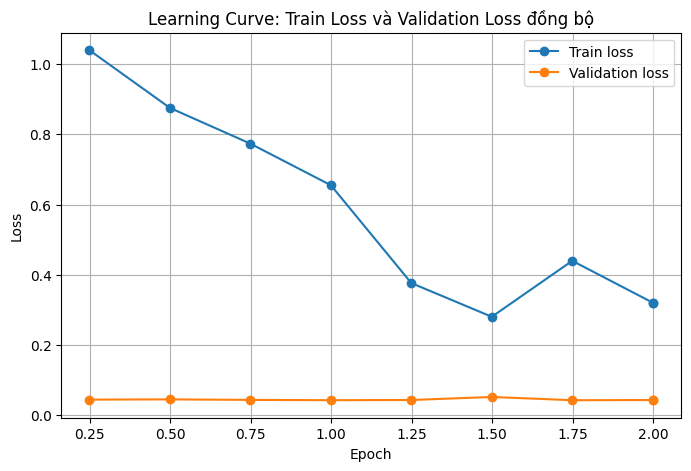

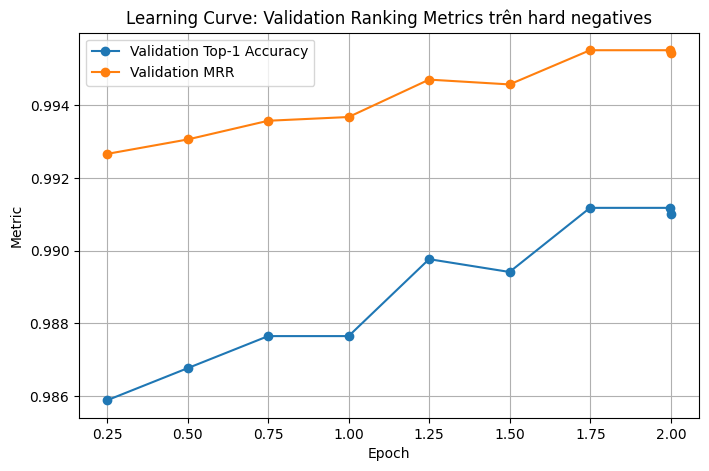

In [30]:
history = pd.DataFrame(trainer.state.log_history)
history.to_csv("./training_log_history_raw.csv", index=False, encoding="utf-8-sig")

print("Bảng 8a. Log huấn luyện gốc từ Trainer")
display(history)

def build_synced_history(history_df: pd.DataFrame) -> pd.DataFrame:
    """Ghép train loss và validation metrics tại cùng mốc step.

    Trainer thường lưu train log và eval log thành hai dòng riêng.
    Hàm này lấy mỗi dòng validation làm mốc, sau đó ghép train loss gần nhất trước hoặc tại cùng step.
    """
    if history_df.empty or "step" not in history_df.columns:
        return pd.DataFrame()

    train_logs = history_df.dropna(subset=["loss"]).copy() if "loss" in history_df.columns else pd.DataFrame()
    eval_logs = history_df.dropna(subset=["eval_loss"]).copy() if "eval_loss" in history_df.columns else pd.DataFrame()

    if eval_logs.empty:
        return pd.DataFrame()

    eval_cols = [
        c for c in [
            "step", "epoch", "eval_loss", "eval_top1_accuracy", "eval_mrr",
            "eval_runtime", "eval_samples_per_second", "eval_steps_per_second"
        ]
        if c in eval_logs.columns
    ]
    eval_logs = eval_logs[eval_cols].sort_values("step")

    if train_logs.empty:
        synced = eval_logs.copy()
        synced["train_loss"] = np.nan
        return synced

    train_cols = [c for c in ["step", "epoch", "loss", "learning_rate"] if c in train_logs.columns]
    train_logs = train_logs[train_cols].sort_values("step")

    synced = pd.merge_asof(
        eval_logs,
        train_logs,
        on="step",
        direction="backward",
        suffixes=("_eval", "_train"),
    )

    if "epoch_eval" in synced.columns:
        synced["epoch"] = synced["epoch_eval"]
    elif "epoch" not in synced.columns and "epoch_train" in synced.columns:
        synced["epoch"] = synced["epoch_train"]

    if "loss" in synced.columns:
        synced = synced.rename(columns={"loss": "train_loss"})

    keep_cols = [
        c for c in [
            "step", "epoch", "train_loss", "eval_loss", "eval_top1_accuracy",
            "eval_mrr", "learning_rate", "eval_runtime",
            "eval_samples_per_second", "eval_steps_per_second"
        ]
        if c in synced.columns
    ]
    return synced[keep_cols]


synced_history = build_synced_history(history)
synced_history.to_csv("./training_log_history_synced.csv", index=False, encoding="utf-8-sig")

print("Bảng 8b. Log train/validation đã đồng bộ theo step")
display(synced_history)

# Learning curve đồng bộ: train loss và validation loss tại cùng mốc step/eval.
plt.figure(figsize=(8, 5))

if not synced_history.empty:
    x = synced_history["epoch"] if "epoch" in synced_history.columns else synced_history["step"]

    if "train_loss" in synced_history.columns:
        plt.plot(x, synced_history["train_loss"], marker="o", label="Train loss")

    if "eval_loss" in synced_history.columns:
        plt.plot(x, synced_history["eval_loss"], marker="o", label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve: Train Loss và Validation Loss đồng bộ")
plt.legend()
plt.grid(True)
plt.show()

# Metric curve: validation top-1 accuracy và MRR theo cùng mốc step/eval.
plt.figure(figsize=(8, 5))

if not synced_history.empty:
    x = synced_history["epoch"] if "epoch" in synced_history.columns else synced_history["step"]

    if "eval_top1_accuracy" in synced_history.columns:
        plt.plot(x, synced_history["eval_top1_accuracy"], marker="o", label="Validation Top-1 Accuracy")

    if "eval_mrr" in synced_history.columns:
        plt.plot(x, synced_history["eval_mrr"], marker="o", label="Validation MRR")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Learning Curve: Validation Ranking Metrics trên hard negatives")
plt.legend()
plt.grid(True)
plt.show()


*Hình 2. Learning curve của train loss và validation loss theo các mốc step/epoch. Biểu đồ dùng để nhận xét mô hình có hội tụ hay không và có dấu hiệu overfitting hay không.*

*Hình 3. Learning curve của validation top-1 accuracy/MRR theo các mốc step/epoch. Metric tăng ổn định thường cho thấy mô hình học được tín hiệu ranking từ dữ liệu.*


### 10.2 Đánh giá trên tập Validation sau fine-tune

In [31]:
val_metrics, val_ranks, val_cm, val_details = evaluate_reranker(
    model,
    tokenizer,
    eval_data=eval_val_data,
    num_negatives=EVAL_NEGATIVES_PER_QUERY,
    batch_size=PER_DEVICE_TRAIN_BATCH_SIZE * (1 + TRAIN_NEGATIVES_PER_QUERY),
    max_length=MAX_LENGTH,
    seed=SEED,
    return_details=True,
    precomputed_negatives=val_ranking_negatives,
)

print("Validation ranking metrics:")
print_metrics(val_metrics)

Evaluating reranker:   0%|          | 0/5667 [00:00<?, ?it/s]

Validation ranking metrics:
MRR@10: 0.9879
NDCG@10: 0.9909
Recall@1: 0.9790
Recall@3: 0.9974
Recall@5: 0.9991
Recall@10: 0.9996
MeanRank: 1.0383
MedianRank: 1.0000
NumQueries: 5667
CandidatesPerQuery: 32
Top1_Accuracy: 0.9987
Top1_Precision: 0.9790
Top1_Recall: 0.9790
Top1_F1: 0.9790
TP: 5548
FP: 119
FN: 119
TN: 175558
NegativeSampling: tfidf_hard


## 11. Đánh giá trên tập Test sau fine-tune

In [32]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("=" * 60)
print("ĐÁNH GIÁ MODEL SAU FINE-TUNE TRÊN TEST SET")
print("=" * 60)
print("Test negative sampling: TF-IDF hard negatives")

finetuned_metrics, finetuned_ranks, finetuned_cm, finetuned_details = evaluate_reranker(
    model,
    tokenizer,
    eval_data=eval_test_data,
    num_negatives=EVAL_NEGATIVES_PER_QUERY,
    batch_size=PER_DEVICE_TRAIN_BATCH_SIZE * (1 + TRAIN_NEGATIVES_PER_QUERY),
    max_length=MAX_LENGTH,
    seed=SEED,
    return_details=True,
    precomputed_negatives=test_ranking_negatives,
)

print_metrics(finetuned_metrics)

os.makedirs("./eval_reranker_finetuned", exist_ok=True)
with open("./eval_reranker_finetuned/metrics.json", "w", encoding="utf-8") as f:
    json.dump(finetuned_metrics, f, ensure_ascii=False, indent=2)

finetuned_details.to_csv("./eval_reranker_finetuned/error_details.csv", index=False, encoding="utf-8-sig")


ĐÁNH GIÁ MODEL SAU FINE-TUNE TRÊN TEST SET
Test negative sampling: TF-IDF hard negatives


Evaluating reranker:   0%|          | 0/5668 [00:00<?, ?it/s]

MRR@10: 0.9845
NDCG@10: 0.9882
Recall@1: 0.9741
Recall@3: 0.9938
Recall@5: 0.9966
Recall@10: 0.9993
MeanRank: 1.0602
MedianRank: 1.0000
NumQueries: 5668
CandidatesPerQuery: 32
Top1_Accuracy: 0.9984
Top1_Precision: 0.9741
Top1_Recall: 0.9741
Top1_F1: 0.9741
TP: 5521
FP: 147
FN: 147
TN: 175561
NegativeSampling: tfidf_hard


### 11.1. Bảng metric định lượng trên Test và so sánh với baseline

Bảng này là kết quả của **một mô hình duy nhất** sau fine-tune. Kết quả so sánh với hai mô hình reranking khác sẽ được tổng hợp ở báo cáo nhóm.


In [33]:
# So sánh baseline pretrained và mô hình sau fine-tune trên cùng test set + cùng hard negatives.
result_summary = pd.DataFrame([
    baseline_metrics,
    finetuned_metrics,
], index=[
    "BGE reranker v2-m3 baseline pretrained",
    "BGE reranker v2-m3 fine-tuned",
])

important_cols = [
    "MRR@10", "NDCG@10", "Recall@1", "Recall@3", "Recall@5", "Recall@10",
    "Top1_Accuracy", "Top1_Precision", "Top1_Recall", "Top1_F1",
    "MeanRank", "MedianRank", "NumQueries", "CandidatesPerQuery",
]
result_summary = result_summary[[c for c in important_cols if c in result_summary.columns]]

print("Bảng 9. So sánh baseline pretrained và BGE reranker v2-m3 fine-tuned trên tập Test")
display(result_summary)

# Bảng delta: giá trị dương nghĩa là fine-tuned cải thiện so với baseline.
higher_is_better = [
    "MRR@10", "NDCG@10", "Recall@1", "Recall@3", "Recall@5", "Recall@10",
    "Top1_Accuracy", "Top1_Precision", "Top1_Recall", "Top1_F1",
]
lower_is_better = ["MeanRank", "MedianRank"]

improvement_rows = []
for col in result_summary.columns:
    if col in ["NumQueries", "CandidatesPerQuery"]:
        continue
    base = result_summary.loc["BGE reranker v2-m3 baseline pretrained", col]
    ft = result_summary.loc["BGE reranker v2-m3 fine-tuned", col]
    if col in higher_is_better:
        delta = ft - base
        direction = "Cao hơn là tốt hơn"
    elif col in lower_is_better:
        delta = base - ft
        direction = "Thấp hơn là tốt hơn"
    else:
        continue
    improvement_rows.append({
        "Metric": col,
        "Baseline": base,
        "Fine-tuned": ft,
        "Cải thiện": delta,
        "Diễn giải": direction,
    })

improvement_summary = pd.DataFrame(improvement_rows)
print("Bảng 9b. Mức cải thiện của fine-tuned so với baseline")
display(improvement_summary)

result_summary.to_csv("./eval_reranker_finetuned/test_metrics_comparison_baseline_vs_finetuned.csv", encoding="utf-8-sig")
improvement_summary.to_csv("./eval_reranker_finetuned/test_metric_improvement.csv", index=False, encoding="utf-8-sig")


Bảng 9. So sánh baseline pretrained và BGE reranker v2-m3 fine-tuned trên tập Test


,MRR@10,NDCG@10,Recall@1,Recall@3,Recall@5,Recall@10,Top1_Accuracy,Top1_Precision,Top1_Recall,Top1_F1,MeanRank,MedianRank,NumQueries,CandidatesPerQuery
BGE reranker v2-m3 baseline pretrained,0.962685,0.969380,0.945836,0.977064,0.983416,0.989767,0.996615,0.945836,0.945836,0.945836,1.273289,1.0,5668,32
BGE reranker v2-m3 fine-tuned,0.984456,0.988172,0.974065,0.993825,0.996648,0.999294,0.998379,0.974065,0.974065,0.974065,1.060162,1.0,5668,32


Bảng 9b. Mức cải thiện của fine-tuned so với baseline


,Metric,Baseline,Fine-tuned,Cải thiện,Diễn giải
0,MRR@10,0.962685,0.984456,0.021771,Cao hơn là tốt hơn
1,NDCG@10,0.969380,0.988172,0.018791,Cao hơn là tốt hơn
2,Recall@1,0.945836,0.974065,0.028229,Cao hơn là tốt hơn
3,Recall@3,0.977064,0.993825,0.016761,Cao hơn là tốt hơn
4,Recall@5,0.983416,0.996648,0.013232,Cao hơn là tốt hơn
5,Recall@10,0.989767,0.999294,0.009527,Cao hơn là tốt hơn
6,Top1_Accuracy,0.996615,0.998379,0.001764,Cao hơn là tốt hơn
7,Top1_Precision,0.945836,0.974065,0.028229,Cao hơn là tốt hơn
8,Top1_Recall,0.945836,0.974065,0.028229,Cao hơn là tốt hơn
9,Top1_F1,0.945836,0.974065,0.028229,Cao hơn là tốt hơn


### 11.2. Confusion Matrix theo top-1 classification view


Bảng 10. Confusion Matrix của mô hình fine-tuned trên Test


,Pred non-relevant,Pred relevant
True non-relevant,175561,147
True relevant,147,5521


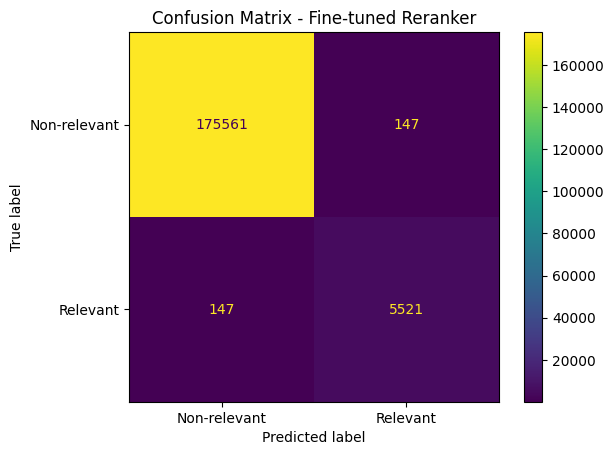

In [34]:
print("Bảng 10. Confusion Matrix của mô hình fine-tuned trên Test")
cm_df = pd.DataFrame(
    finetuned_cm,
    index=["True non-relevant", "True relevant"],
    columns=["Pred non-relevant", "Pred relevant"],
)
display(cm_df)

disp = ConfusionMatrixDisplay(
    confusion_matrix=finetuned_cm,
    display_labels=["Non-relevant", "Relevant"],
)
disp.plot(values_format="d")
plt.title("Confusion Matrix - Fine-tuned Reranker")
plt.show()


*Hình 4. Confusion Matrix của mô hình fine-tuned trên test set theo top-1 classification view. Một query được xem là đúng nếu passage positive được xếp ở vị trí top 1.*


### 11.3. Biểu đồ so sánh baseline và mô hình fine-tuned


<Figure size 1000x500 with 0 Axes>

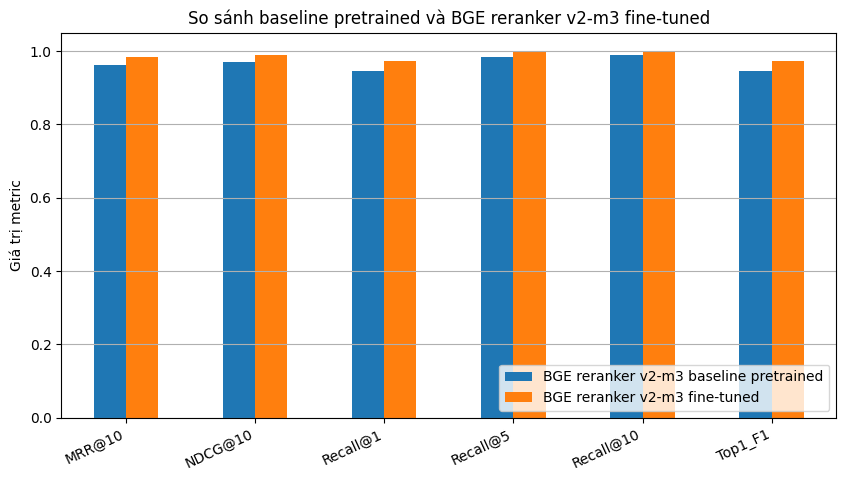

In [35]:
plot_cols = [c for c in ["MRR@10", "NDCG@10", "Recall@1", "Recall@5", "Recall@10", "Top1_F1"] if c in result_summary.columns]

plot_df = result_summary.loc[
    ["BGE reranker v2-m3 baseline pretrained", "BGE reranker v2-m3 fine-tuned"],
    plot_cols,
].T

plt.figure(figsize=(10, 5))
plot_df.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Giá trị metric")
plt.title("So sánh baseline pretrained và BGE reranker v2-m3 fine-tuned")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.show()


*Hình 5. Biểu đồ so sánh các metric chính giữa baseline pretrained và mô hình `BAAI/bge-reranker-v2-m3` sau fine-tune trên cùng test set với cùng TF-IDF hard negatives.*

## 12. Thảo luận: Overfitting/Underfitting và mức độ hội tụ

Cell dưới đây tự động đưa ra nhận xét sơ bộ dựa trên log huấn luyện. Khi viết báo cáo, cần kết hợp với quan sát trực tiếp learning curves.


In [36]:
def analyze_training_behavior(history_df: pd.DataFrame):
    comments = []

    train_logs = history_df.dropna(subset=["loss"]) if "loss" in history_df.columns else pd.DataFrame()
    eval_logs = history_df.dropna(subset=["eval_loss"]) if "eval_loss" in history_df.columns else pd.DataFrame()

    if len(train_logs) >= 2:
        first_train = float(train_logs["loss"].iloc[0])
        last_train = float(train_logs["loss"].iloc[-1])
        if last_train < first_train:
            comments.append("Train loss giảm so với ban đầu, cho thấy mô hình có học được tín hiệu từ dữ liệu.")
        else:
            comments.append("Train loss chưa giảm rõ ràng; có thể cần tăng epoch, kiểm tra learning rate hoặc chất lượng dữ liệu.")

    if len(eval_logs) >= 2:
        first_eval = float(eval_logs["eval_loss"].iloc[0])
        last_eval = float(eval_logs["eval_loss"].iloc[-1])
        if last_eval <= first_eval:
            comments.append("Validation loss không tăng so với ban đầu, chưa thấy dấu hiệu overfitting rõ rệt.")
        else:
            comments.append("Validation loss tăng, trong khi train loss có thể giảm; đây là dấu hiệu cần kiểm tra overfitting.")

    if "eval_top1_accuracy" in history_df.columns:
        metric_logs = history_df.dropna(subset=["eval_top1_accuracy"])
        if len(metric_logs) >= 2:
            first_acc = float(metric_logs["eval_top1_accuracy"].iloc[0])
            last_acc = float(metric_logs["eval_top1_accuracy"].iloc[-1])
            if last_acc >= first_acc:
                comments.append("Validation top-1 accuracy tăng hoặc giữ ổn định, cho thấy chất lượng ranking cải thiện.")
            else:
                comments.append("Validation top-1 accuracy giảm; cần kiểm tra overfitting hoặc negative sampling quá nhiễu.")

    if not comments:
        comments.append("Chưa đủ log để kết luận. Cần chạy training ít nhất 2 epoch hoặc tăng logging/evaluation.")

    return comments

print("Nhận xét sơ bộ về quá trình học:")
for c in analyze_training_behavior(history):
    print("-", c)


Nhận xét sơ bộ về quá trình học:
- Train loss giảm so với ban đầu, cho thấy mô hình có học được tín hiệu từ dữ liệu.
- Validation loss không tăng so với ban đầu, chưa thấy dấu hiệu overfitting rõ rệt.
- Validation top-1 accuracy tăng hoặc giữ ổn định, cho thấy chất lượng ranking cải thiện.


Một số hướng xử lý nếu có overfitting:

- Giảm số epoch.
- Tăng weight decay.
- Dùng early stopping.
- Tăng chất lượng negatives thay vì chỉ tăng số lượng.
- Chunk passage dài để tránh mất thông tin quan trọng do truncation.
- Dùng validation set cố định và không điều chỉnh theo test set.


## 13. Phân tích lỗi

Phần này lấy các trường hợp mà positive passage không được xếp top 1. Các mẫu này nên được đưa vào báo cáo để giải thích nguyên nhân sai.


In [37]:
def error_table_from_details(details_df: pd.DataFrame, max_rows: int = 20) -> pd.DataFrame:
    if details_df.empty:
        return details_df

    errors = details_df[details_df["positive_rank"] > 1].copy()
    if errors.empty:
        return errors

    errors["query_short"] = errors["query"].str.slice(0, 250)
    errors["positive_short"] = errors["positive_passage"].str.slice(0, 350)
    errors["predicted_top_short"] = errors["predicted_top_passage"].str.slice(0, 350)
    errors["score_gap_top_minus_positive"] = errors["top_score"] - errors["positive_score"]

    cols = [
        "positive_rank",
        "score_gap_top_minus_positive",
        "query_short",
        "positive_short",
        "predicted_top_short",
    ]
    return errors[cols].sort_values(["positive_rank", "score_gap_top_minus_positive"], ascending=[False, False]).head(max_rows)

error_examples = error_table_from_details(finetuned_details, max_rows=20)

print("Bảng 11. Một số trường hợp mô hình fine-tuned xếp sai trên Test")
display(error_examples)

error_examples.to_csv("./eval_reranker_finetuned/error_examples_for_report.csv", index=False, encoding="utf-8-sig")


Bảng 11. Một số trường hợp mô hình fine-tuned xếp sai trên Test


,positive_rank,score_gap_top_minus_positive,query_short,positive_short,predicted_top_short
2119,23,0.562500,Người sử dụng lao động phải thông báo trước ba...,Bộ Luật Lao Động Việt Nam 2019 quy định các ti...,Điều 177. Nghĩa vụ của người sử dụng lao động ...
192,19,0.890625,Người lao động có quyền nghỉ không hưởng lương...,Bộ Luật Lao Động Việt Nam 2019 quy định các ti...,Tôi làm việc tại một công ty TNHH. Công ty tôi...
4403,13,7.617188,Người sử dụng lao động phải trả tiền lương thử...,Bộ Luật Lao Động Việt Nam 2019 quy định các ti...,Điều 26. Tiền lương thử việc Tiền lương của ng...
3518,11,13.928711,Quy định về lựa chọn nhà thầu trong trường hợp...,Đơn vị chúng tôi là Trung tâm tư vấn và Kiểm đ...,Từ khi Nghị định số 63/2014/NĐ-CP có hiệu lực ...
1643,10,1.625000,Người sử dụng lao động có trách nhiệm gì khi n...,Chương VI của Bộ luật Lao động Việt Nam quy đị...,Điều 395. Nghĩa vụ của người sử dụng lao động ...
644,9,21.738281,Người lao động có được trả lương theo sản phẩm...,Chương VI của Bộ luật Lao động Việt Nam quy đị...,"Người lao động được trả lương theo thời gian, ..."
2585,9,14.931458,"UBND huyện quyết định danh sách, kinh phí hỗ trợ",Tôi làm việc tại một công ty TNHH. Công ty tôi...,"Mẹ và hai con nhỏ của tôi là F1, đi cách ly tậ..."
3593,9,4.937500,Người lao động có thể yêu cầu trả lương bằng t...,Chương VI của Bộ luật Lao động Việt Nam quy đị...,"Người lao động được trả lương theo thời gian, ..."
5281,8,12.400391,Chia sẻ bài viết đăng trên Facebook của người ...,Theo Điều 25 Luật Sở hữu trí tuệ 2005 được sửa...,Điều 191. Quyền sử dụng của người không phải l...
1470,7,17.390625,Tôi đang chuẩn bị ký một hợp đồng với một ngườ...,"Điều 86. Hợp đồng, giao dịch của công ty với n...",Điều 401. Hiệu lực của hợp đồng 1. Hợp đồng đư...


Gợi ý phân tích lỗi trong báo cáo:

- **Nhiễu nhãn**: positive passage trong dataset có thể chưa phải đoạn phù hợp nhất.
- **Nhiều đoạn cùng đúng**: negative lấy từ dataset khác có thể cũng liên quan về mặt pháp lý.
- **Passage quá dài bị cắt**: thông tin quan trọng có thể nằm sau vị trí `MAX_LENGTH`.
- **Khớp từ vựng gây nhiễu**: đoạn sai có nhiều thuật ngữ giống query nên được score cao.
- **Thiếu ngữ cảnh pháp lý**: một số câu hỏi cần điều luật, khoản, nghị định cụ thể mà passage không nêu đầy đủ.


## 14. Test inference thủ công

In [38]:
sample_query = "Người lao động nghỉ việc có được hưởng trợ cấp thôi việc không?"
sample_passage_good = "Người lao động đã làm việc thường xuyên từ đủ 12 tháng trở lên khi chấm dứt hợp đồng lao động đúng quy định có thể được người sử dụng lao động chi trả trợ cấp thôi việc, trừ các trường hợp pháp luật loại trừ."
sample_passage_bad = "Doanh nghiệp phải kê khai thuế giá trị gia tăng theo tháng hoặc theo quý tùy thuộc điều kiện pháp luật về thuế."

pairs = [
    (sample_query, sample_passage_good),
    (sample_query, sample_passage_bad),
]

raw_scores = score_pairs(model, tokenizer, pairs, batch_size=2, max_length=MAX_LENGTH, normalize=False)
norm_scores = score_pairs(model, tokenizer, pairs, batch_size=2, max_length=MAX_LENGTH, normalize=True)

for pair, raw, norm in zip(pairs, raw_scores, norm_scores):
    print("=" * 80)
    print("Query:", pair[0])
    print("Passage:", pair[1])
    print(f"Raw score: {raw:.4f}")
    print(f"Sigmoid score: {norm:.4f}")


Query: Người lao động nghỉ việc có được hưởng trợ cấp thôi việc không?
Passage: Người lao động đã làm việc thường xuyên từ đủ 12 tháng trở lên khi chấm dứt hợp đồng lao động đúng quy định có thể được người sử dụng lao động chi trả trợ cấp thôi việc, trừ các trường hợp pháp luật loại trừ.
Raw score: -12.4766
Sigmoid score: 0.0000
Query: Người lao động nghỉ việc có được hưởng trợ cấp thôi việc không?
Passage: Doanh nghiệp phải kê khai thuế giá trị gia tăng theo tháng hoặc theo quý tùy thuộc điều kiện pháp luật về thuế.
Raw score: -16.0156
Sigmoid score: 0.0000


## 15. Lưu model, kết quả và nén artifact

In [39]:
# Lưu lại toàn bộ kết quả cần cho báo cáo.
os.makedirs("./report_artifacts", exist_ok=True)

split_summary.to_csv("./report_artifacts/table_2_split_summary.csv", index=False, encoding="utf-8-sig")
source_summary.to_csv("./report_artifacts/table_3_source_distribution.csv", index=False, encoding="utf-8-sig")
arch_summary.to_csv("./report_artifacts/table_6_architecture.csv", index=False, encoding="utf-8-sig")
hyperparam_table.to_csv("./report_artifacts/table_7_hyperparameters.csv", index=False, encoding="utf-8-sig")
history.to_csv("./report_artifacts/table_8a_training_log_raw.csv", index=False, encoding="utf-8-sig")
synced_history.to_csv("./report_artifacts/table_8b_training_log_synced.csv", index=False, encoding="utf-8-sig")
result_summary.to_csv("./report_artifacts/table_9_test_metrics_baseline_vs_finetuned.csv", encoding="utf-8-sig")
improvement_summary.to_csv("./report_artifacts/table_9b_metric_improvement.csv", index=False, encoding="utf-8-sig")
cm_df.to_csv("./report_artifacts/table_10_confusion_matrix.csv", encoding="utf-8-sig")
error_examples.to_csv("./report_artifacts/table_11_error_examples.csv", index=False, encoding="utf-8-sig")
finetuned_details.to_csv("./report_artifacts/test_error_details_full.csv", index=False, encoding="utf-8-sig")
baseline_details.to_csv("./report_artifacts/baseline_error_details_full.csv", index=False, encoding="utf-8-sig")

print("Đã lưu artifacts vào ./report_artifacts")


Đã lưu artifacts vào ./report_artifacts


In [ ]:
!zip -r vietlaw-bge-reranker-v2-m3-finetuned.zip vietlaw-bge-reranker-v2-m3-finetuned/ report_artifacts/ training_log_history_raw.csv training_log_history_synced.csv


  adding: vietlaw-bge-reranker-v2-m3-finetuned/ (stored 0%)
  adding: vietlaw-bge-reranker-v2-m3-finetuned/checkpoint-2891/ (stored 0%)
  adding: vietlaw-bge-reranker-v2-m3-finetuned/checkpoint-2891/config.json (deflated 50%)
  adding: vietlaw-bge-reranker-v2-m3-finetuned/checkpoint-2891/model.safetensors

## 16. Kết luận mẫu cho báo cáo

Sau khi chạy notebook, phần kết luận nên dựa trên số liệu thực tế ở `Bảng 9`, `Bảng 9b`, `Hình 2`, `Hình 3`, `Hình 5` và `Bảng 11`.

Mẫu kết luận:

> Kết quả thực nghiệm cho thấy mô hình `BAAI/bge-reranker-v2-m3` sau fine-tune cần được so sánh với baseline pretrained của cùng kiến trúc trên cùng test set và cùng TF-IDF hard negatives. Nếu các metric như MRR@10, NDCG@10, Recall@1, Recall@10 và Top1_F1 tăng so với baseline, có thể kết luận fine-tuning giúp mô hình thích nghi tốt hơn với miền pháp luật tiếng Việt. Learning curves trên tập train/validation được sử dụng để đánh giá mức độ hội tụ và phát hiện overfitting/underfitting. Một số lỗi có thể xuất hiện khi negative passage có thuật ngữ pháp lý gần với query, khi positive passage quá dài bị cắt bớt do `MAX_LENGTH`, hoặc khi có nhiều passage cùng đúng về mặt ngữ nghĩa. Trong báo cáo nhóm, kết quả của mô hình này sẽ được so sánh với hai mô hình reranking khác do các thành viên còn lại thực hiện.

## 17. Tài liệu tham khảo và nguồn

1. BAAI. `BAAI/bge-reranker-v2-m3`, Hugging Face model card.  
2. Xiao et al. BGE-M3: Multi-Lingual, Multi-Functionality, Multi-Granularity Text Embeddings.  
3. Vaswani et al. *Attention Is All You Need*.  
4. Hugging Face Transformers Documentation.  
5. Hugging Face Datasets Documentation.
